# Per-garden GWAS — class-only new peaks across gardens (dot grid)

Which genes does the non-SNP / SV scan flag that the SNP scan misses, and in which gardens?
One dot per (gene, garden) where that gene's tiling block carries a Bonferroni-significant
non-SNP/SV lead. Layout follows `newpeak_dotgrid_lfmm_nonsnp.ipynb`, with **gardens as columns
ordered cold → hot** instead of climate axes.

- **dot size** = −log10 p of the block's lead record
- **dot colour** = TAIR-GO + UniProt functional category
- **solid, black-edged** = class-only (the SNP-blind peaks); **faded, white-edged** = the SNP
  scan is also significant in that block, kept for context rather than filtered away
- **right-hand bar** = |alt_len − ref_len| for the lead variant, log scale; rows ordered by size

> ⚠️ Cross-garden recurrence here is **descriptive, not a tested contrast** — the cross-garden
> test was the meta this analysis deliberately dropped, and all 30 gardens share one founder
> panel and one `p0`, so their scans are correlated by construction. Low-frequency markers also
> dominate the underlying hit list (see the MAC caveat in `persite_gwas.ipynb`).

In [1]:

import os, sys
import numpy as np, pandas as pd
from scipy import stats
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.lines as mlines
os.chdir("/global/scratch/projects/fc_moilab/tbellg/kmate")
sys.path.insert(0, "analysis/grenenet_selection")
sys.path.insert(0, "analysis/grenenet_selection/blocks")
import lib, blocks_tiling as bt
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

RES = "analysis/grenenet_selection/r3_persite_gwas/results/gemma_gwas_mac12"
PLOTS = f"{RES}/plots"; os.makedirs(PLOTS, exist_ok=True)
CH = ["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"]

def load(name):
    d = np.load(f"{RES}/persite_gwas_{name}.npz", allow_pickle=True)
    chrom = np.array([c.replace("chr", "Chr") for c in d["chrom"].astype(str)])
    pos = d["pos"].astype(np.int64)
    # UNMERGED tiling: fixed by panel LD, so identical across classes -- see builder docstring
    blk = np.asarray(bt.assign_tiling(chrom, pos, r2=0.9), dtype=object)
    return dict(chrom=chrom, pos=pos, P=d["P"], blk=blk,
                sites=[int(s) for s in d["sites"]], bio1=d["bio1"].astype(float))

SNP = load("snp")
sites = SNP["sites"]; bio1 = SNP["bio1"]
site_bio1 = {s: float(b) for s, b in zip(sites, bio1)}
site_order = sorted(sites, key=lambda s: site_bio1[s])          # cold -> hot
GENES = lib.load_genes()

CHROM_LEN = {c: int(SNP["pos"][SNP["chrom"] == c].max()) for c in CH}
OFF, _cum = {}, 0
for c in CH:
    OFF[c] = _cum; _cum += CHROM_LEN[c]
GENOME = _cum

def gpos(chrom, pos):
    return np.array([OFF[c] for c in chrom]) + pos

def genes_on(blk_id, d):
    """Gene symbols overlapping a block's span (+/-2 kb promoter)."""
    m = d["blk"] == blk_id
    if not m.any():
        return []
    ch = d["chrom"][m][0]; lo, hi = d["pos"][m].min() - 2000, d["pos"][m].max() + 2000
    g = GENES[(GENES.chrom.astype(str).str.replace("chr", "Chr") == ch) &
              (GENES.end > lo) & (GENES.start < hi)]
    col = "symbol" if "symbol" in g.columns else g.columns[-1]
    return [str(x) for x in g[col].dropna().unique()[:4]]

print(f"{len(sites)} gardens, bio1 {bio1.min():.1f}-{bio1.max():.1f} C; "
      f"snp {len(SNP['pos']):,} markers")


30 gardens, bio1 6.0-21.6 C; snp 1,111,228 markers


In [2]:

def lam_gc(p):
    p = np.clip(np.asarray(p, float), 1e-300, 1.0)
    p = p[np.isfinite(p)]
    return float(np.median(stats.chi2.isf(p, 1)) / stats.chi2.isf(0.5, 1))

def qq_xy(p, keep_head=8000, n_bulk=2500):
    """Observed vs expected -log10p; keep the whole significant tail, thin the dense bulk."""
    p = np.sort(np.clip(np.asarray(p, float)[np.isfinite(p)], 1e-300, 1.0))
    n = len(p)
    exp = -np.log10((np.arange(n) + 0.5) / n); obs = -np.log10(p)
    if n <= keep_head + n_bulk:
        idx = np.arange(n)
    else:
        idx = np.concatenate([np.arange(keep_head),
                              np.unique(np.geomspace(keep_head, n - 1, n_bulk).astype(int))])
    return exp[idx], obs[idx]

def leads(d, si):
    """Per block, the record with the smallest p in garden si. Returns DataFrame."""
    p = d["P"][:, si]
    ok = np.isfinite(p)
    df = pd.DataFrame(dict(blk=d["blk"][ok], chrom=d["chrom"][ok], pos=d["pos"][ok],
                           nlp=-np.log10(np.clip(p[ok], 1e-300, 1))))
    return df.loc[df.groupby("blk")["nlp"].idxmax()]

def new_peaks(cd, si, snp_lead=None):
    """Blocks whose CLASS lead clears Bonferroni while the SNP lead in the SAME block does not."""
    sl = leads(SNP, si) if snp_lead is None else snp_lead
    cl = leads(cd, si)
    bs = -np.log10(0.05 / np.isfinite(SNP["P"][:, si]).sum())
    bc = -np.log10(0.05 / np.isfinite(cd["P"][:, si]).sum())
    m = cl.merge(sl[["blk", "nlp"]], on="blk", how="left", suffixes=("", "_snp"))
    m["nlp_snp"] = m["nlp_snp"].fillna(0.0)
    m["snp_also"] = m["nlp_snp"] > bs
    return m[m["nlp"] > bc].copy(), bs, bc

SNP_DARK, SNP_LIGHT = "#3B3B3B", "#9A9A9A"
CLS_COL = {"nonsnp": ("#C1560F", "#E8A87C"), "sv": ("#2E7D32", "#88C68B")}


## Collect class-only peaks and their genes

In [3]:

# Collect every class-only ("new") peak across gardens, for BOTH non-SNP and SV.
ALL = []
for CLS in ["nonsnp", "sv"]:
    CD = load(CLS)
    for s in site_order:
        si = sites.index(s)
        npk, bs, bc = new_peaks(CD, si)
        for _, r in npk.iterrows():
            for g in (genes_on(r.blk, CD) or [r.blk]):
                ALL.append(dict(cls=CLS, garden=s, bio1=site_bio1[s], blk=r.blk, gene=g,
                                chrom=r.chrom, pos=int(r.pos), nlp=float(r.nlp),
                                snp_also=bool(r.snp_also)))
ALL = pd.DataFrame(ALL)
ALL.to_csv(f"{RES}/persite_newpeak_genes.csv", index=False)
print(f"{len(ALL)} (gene, garden) cells | {ALL.gene.nunique()} genes | "
      f"class-only {int((~ALL.snp_also).sum())} vs SNP-also {int(ALL.snp_also.sum())}")
print(ALL.groupby("cls").agg(cells=("gene", "size"), genes=("gene", "nunique")).to_string())


104 (gene, garden) cells | 43 genes | class-only 96 vs SNP-also 8
        cells  genes
cls                 
nonsnp     57     40
sv         47      6


## Variant size and functional category

In [4]:

# variant size (bp) per position, from the SAME panel meta the scan was built from
SIZE = {}
for _ci in range(1, 6):
    _m = np.load(f"{lib.PROJ}/panel/arch3/chr{_ci}/var_pa_231_arch3_chr{_ci}.meta.npz",
                 allow_pickle=True)
    _p = _m["pos"].astype(np.int64)
    _d = np.abs(_m["alt_len"].astype(int) - _m["ref_len"].astype(int))
    for q, dd in zip(_p, _d):                       # max per pos (multiallelic)
        k = (f"Chr{_ci}", int(q))
        if dd > SIZE.get(k, -1):
            SIZE[k] = int(dd)
ALL["size_bp"] = [SIZE.get((c, p), np.nan) for c, p in zip(ALL.chrom, ALL.pos)]
print(f"size attached for {ALL.size_bp.notna().mean():.1%} of cells; "
      f"median {ALL.size_bp.median():.0f} bp, max {ALL.size_bp.max():.0f} bp")


size attached for 100.0% of cells; median 94 bp, max 4530 bp


In [5]:

# functional category per gene -- TAIR GO + UniProt (the mandated annotator). Degrades to
# "unclassified" if outbound HTTPS is unavailable, so the grid still renders.
CATS, ann = {}, None
try:
    import importlib.util as _ilu
    _p = "analysis/grenenet_selection/r2_gea_nonsnp/phase1_replication/annotate_genes_tair_uniprot.py"
    if not os.path.exists(_p):
        _p = "analysis/grenenet_selection/archive_gea/phase1_replication/annotate_genes_tair_uniprot.py"
    _s = _ilu.spec_from_file_location("ann", _p); ann = _ilu.module_from_spec(_s)
    _s.loader.exec_module(ann)
    print("annotator loaded:", _p)
except Exception as e:
    print("annotator unavailable ->", type(e).__name__, e)

genes = sorted(ALL.gene.unique())
if ann is not None:
    try:
        # annotate() returns columns gene / symbol / ... / `categories` (PLURAL, comma-joined,
        # empty string when nothing matched) -- not `category`.
        res = ann.annotate(genes)
        res.to_csv(f"{RES}/persite_newpeak_gene_annotation.csv", index=False)
        CATS = {r.gene: (str(r.categories).split(",")[0] if str(r.categories).strip() else
                         "unclassified") for r in res.itertuples()}
        SYM = {r.gene: (r.symbol or r.gene) for r in res.itertuples()}
        NAME = {r.gene: r.protein_name for r in res.itertuples()}
    except Exception as e:
        print(f"  annotate() failed: {type(e).__name__}: {e}")
        SYM, NAME = {}, {}
else:
    SYM, NAME = {}, {}
ALL["category"] = [CATS.get(g, "unclassified") for g in ALL.gene]
ALL["symbol"] = [SYM.get(g, g) for g in ALL.gene]
print(f"\ncategories assigned: {(ALL.category != 'unclassified').sum()}/{len(ALL)} cells, "
      f"{ALL.loc[ALL.category != 'unclassified', 'gene'].nunique()}/{ALL.gene.nunique()} genes")
print(ALL.drop_duplicates('gene').category.value_counts().to_string())


annotator loaded: analysis/grenenet_selection/r2_gea_nonsnp/phase1_replication/annotate_genes_tair_uniprot.py
annotating 43 genes

-- TAIR GAF (GO Consortium) --


GAF cache: /global/scratch/projects/fc_moilab/tbellg/kmate/analysis/grenenet_selection/r2_gea_nonsnp/phase1_replication/results/cache/tair.gaf.gz (7.2 MB)


   GO for 33/43 genes
-- UniProt REST pass 1: reviewed / Swiss-Prot (taxid 3702) --


  uniprot 40/43 -> 28 mapped


  uniprot 43/43 -> 29 mapped


   reviewed: 29/43 genes
-- UniProt REST pass 2: unreviewed / TrEMBL for the remaining 14 --


  uniprot 14/14 -> 12 mapped


   UniProt total: 41/43 genes
-- mygene.info (kept for GO term NAMES + entrez) --



categories assigned: 53/104 cells, 14/43 genes
category
unclassified    29
water            4
defense          4
light            2
flowering        2
calcium          1
oxidative        1


## The dot grid

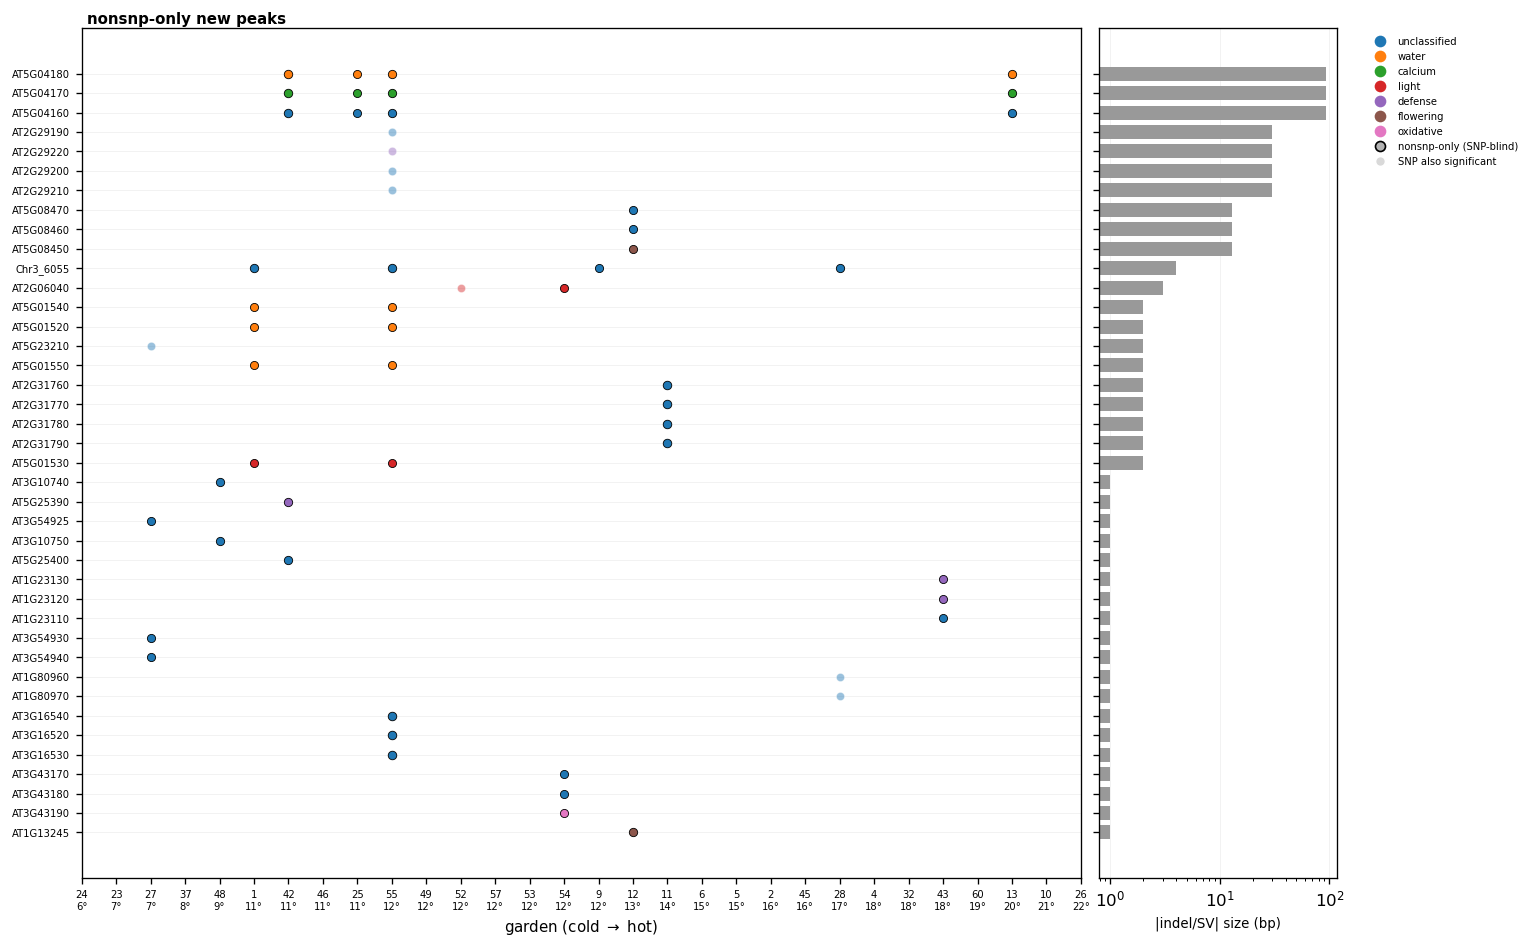

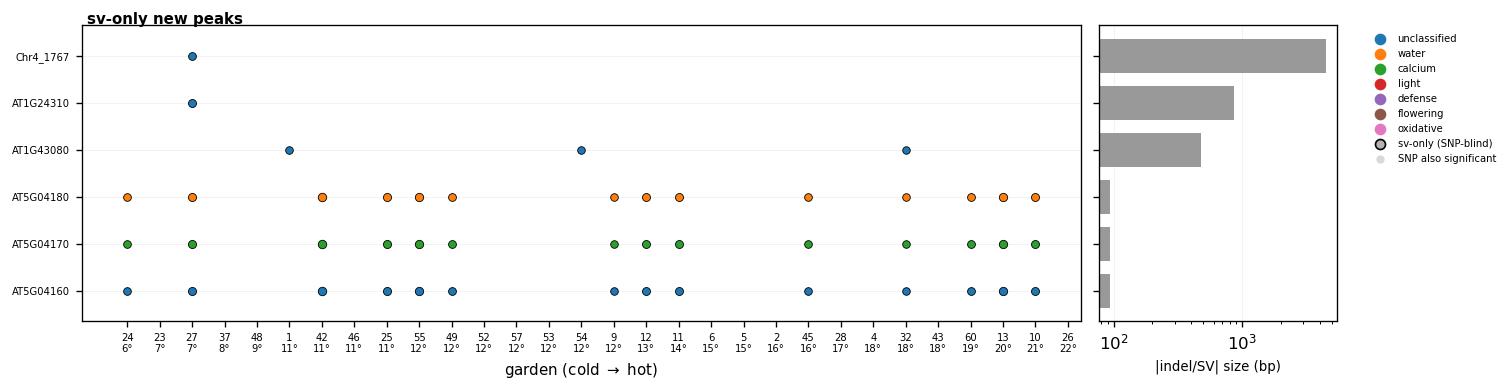

In [6]:

CAT_ORDER = [c for c in ALL.category.value_counts().index]
PAL = plt.cm.tab10.colors + plt.cm.Set3.colors
CCOL = {c: PAL[i % len(PAL)] for i, c in enumerate(CAT_ORDER)}
xpos = {s: i for i, s in enumerate(site_order)}

for CLS in ["nonsnp", "sv"]:
    sub = ALL[ALL.cls == CLS]
    if not len(sub):
        print(f"no {CLS} new peaks to plot"); continue
    # rows ordered by |variant size| (largest at top), matching the reference dot grid
    gsz = sub.groupby("gene").size_bp.max().fillna(0).sort_values()
    gord = list(gsz.index)
    yidx = {g: i for i, g in enumerate(gord)}
    h = max(3.2, 0.23 * len(gord))
    fig, (ax, axr) = plt.subplots(1, 2, figsize=(13.5, h), sharey=True,
                                  gridspec_kw={"width_ratios": [4.2, 1], "wspace": 0.03})
    for _, r in sub.iterrows():
        ax.scatter(xpos[r.garden], yidx[r.gene], s=10 + r.nlp * 2.0,
                   c=[CCOL[r.category]], alpha=0.45 if r.snp_also else 1.0,
                   edgecolors="white" if r.snp_also else "black",
                   linewidths=0.5, zorder=3)
    ax.set_xticks(range(len(site_order)))
    ax.set_xticklabels([f"{s}\n{site_bio1[s]:.0f}\u00b0" for s in site_order], fontsize=6)
    ax.set_yticks(range(len(gord))); ax.set_yticklabels(gord, fontsize=6)
    ax.set_xlabel("garden (cold $\\rightarrow$ hot)", fontsize=9)
    ax.grid(axis="y", lw=0.3, color="0.9", zorder=0)
    ax.set_axisbelow(True)
    ax.annotate(f"{CLS}-only new peaks", xy=(0.005, 1.005), xycoords="axes fraction",
                fontsize=9, weight="bold")
    sizes = gsz.reindex(gord).fillna(0).to_numpy()
    axr.barh(range(len(gord)), np.maximum(sizes, 1), height=0.72, color="0.6")
    axr.set_xscale("log"); axr.set_xlabel("|indel/SV| size (bp)", fontsize=8)
    axr.grid(axis="x", lw=0.3, color="0.9"); axr.set_axisbelow(True)
    handles = [mlines.Line2D([], [], marker="o", ls="", ms=6, color=CCOL[c], label=c)
               for c in CAT_ORDER]
    handles += [mlines.Line2D([], [], marker="o", ls="", ms=6, mfc="0.7", mec="black",
                              label=f"{CLS}-only (SNP-blind)"),
                mlines.Line2D([], [], marker="o", ls="", ms=6, mfc="0.85", mec="white",
                              label="SNP also significant")]
    ax.legend(handles=handles, fontsize=6, loc="upper left", bbox_to_anchor=(1.28, 1.0),
              frameon=False)
    fig.savefig(f"{PLOTS}/newpeak_dotgrid_{CLS}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)
